#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Data

In [3]:
rna = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/TCGA_Pan_rna_met.csv', index_col = 0)
rna

,ENSG00000211592,ENSG00000211592.1,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000198899,ENSG00000198886,ENSG00000212907,ENSG00000198763,ENSG00000198840,...,ENSG00000205923,ENSG00000183747,ENSG00000066813,ENSG00000182601,ENSG00000156885,ENSG00000182156,ENSG00000166948,ENSG00000197838,ENSG00000167751,ENSG00000182415
TCGA-D8-A146-01A-31R-A115-07,7654.8063,7654.8063,24344.3785,16191.8522,19880.8536,13343.2173,17287.6749,5208.1979,12236.5064,12141.7301,...,0.0,0.0402,0.0162,0.1149,0.1394,0.0562,0.0000,0.0749,0.0831,0.0
TCGA-AQ-A0Y5-01A-11R-A14M-07,10.8013,10.8013,15466.3528,22624.9765,22247.2836,12629.4103,18353.2198,7174.4777,9078.7267,7283.1951,...,0.0,0.0000,0.0152,0.0902,0.0000,0.0000,0.0000,0.0000,0.1173,0.0
TCGA-C8-A274-01A-11R-A16F-07,216.4474,216.4474,21705.3843,38997.7958,44549.4302,19402.3325,26656.2610,10667.9069,12433.0264,8790.3434,...,0.0,0.0000,0.0056,0.0000,0.0000,0.0131,0.0000,0.6273,0.0290,0.0
TCGA-BH-A0BD-01A-11R-A034-07,6638.7969,6638.7969,18827.2409,21883.2759,15965.1102,11529.3431,15270.5690,4447.9230,8573.9467,6671.0148,...,0.0,0.0142,0.0071,0.1014,0.1230,0.0000,0.0000,2.2483,0.0733,0.0
TCGA-B6-A1KC-01B-11R-A157-07,74.1970,74.1970,60674.8928,57117.7119,50484.0015,31332.4075,51830.2106,14107.8244,26561.6817,13483.2529,...,0.0,0.0049,0.0000,0.0232,0.1692,0.0000,0.0348,0.0455,0.0126,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-CV-7432-01A-11R-2132-07,200.9838,200.9838,8671.9002,8741.8746,8644.1557,4321.6458,6091.2729,1681.5885,3209.1371,2681.5934,...,0.0,0.0000,0.0000,0.0641,0.0000,0.0000,0.0000,0.0000,0.0000,0.0
TCGA-IQ-7630-01A-11R-2081-07,139.9574,139.9574,18694.5686,18814.4110,12031.4254,10710.0588,24906.4334,6064.0890,11586.6298,15659.8229,...,0.0,0.0000,0.0057,0.0000,0.5877,0.2762,0.0202,0.1053,0.0438,0.0
TCGA-H7-A6C4-11A-21R-A466-07,268.1355,268.1355,41358.3291,49317.1032,54541.9472,30144.6238,35882.9666,10965.0446,22592.2763,29516.4712,...,0.0,0.0000,0.0000,0.7466,500.2332,0.0000,2.8753,0.0000,0.0000,0.0
TCGA-H7-8501-01A-11R-2403-07,5129.2628,5129.2628,4904.7972,5029.7445,2911.5653,2025.7448,3771.5628,962.7505,1291.5879,2108.7338,...,0.0,0.0000,0.0121,0.0286,0.2083,0.0839,0.0429,0.0560,0.0000,0.0


In [4]:
drop_cols = []
for i in rna.columns:
  if i.endswith('.1'):
    drop_cols.append(i)
    print(i)

ENSG00000211592.1


In [5]:
rna = rna.drop(columns = drop_cols)
for i in rna.columns:
  if i.endswith('.1'):
    print(i)

In [6]:
rna.head(3)

,ENSG00000211592,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000198899,ENSG00000198886,ENSG00000212907,ENSG00000198763,ENSG00000198840,ENSG00000156508,...,ENSG00000205923,ENSG00000183747,ENSG00000066813,ENSG00000182601,ENSG00000156885,ENSG00000182156,ENSG00000166948,ENSG00000197838,ENSG00000167751,ENSG00000182415
TCGA-D8-A146-01A-31R-A115-07,7654.8063,24344.3785,16191.8522,19880.8536,13343.2173,17287.6749,5208.1979,12236.5064,12141.7301,1774.5191,...,0.0,0.0402,0.0162,0.1149,0.1394,0.0562,0.0,0.0749,0.0831,0.0
TCGA-AQ-A0Y5-01A-11R-A14M-07,10.8013,15466.3528,22624.9765,22247.2836,12629.4103,18353.2198,7174.4777,9078.7267,7283.1951,2156.9917,...,0.0,0.0000,0.0152,0.0902,0.0000,0.0000,0.0,0.0000,0.1173,0.0
TCGA-C8-A274-01A-11R-A16F-07,216.4474,21705.3843,38997.7958,44549.4302,19402.3325,26656.2610,10667.9069,12433.0264,8790.3434,1560.1601,...,0.0,0.0000,0.0056,0.0000,0.0000,0.0131,0.0,0.6273,0.0290,0.0


#Log2 transformation

In [7]:
rna = rna.apply(lambda x: np.log2(x + 1))
rna.head(3)

,ENSG00000211592,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000198899,ENSG00000198886,ENSG00000212907,ENSG00000198763,ENSG00000198840,ENSG00000156508,...,ENSG00000205923,ENSG00000183747,ENSG00000066813,ENSG00000182601,ENSG00000156885,ENSG00000182156,ENSG00000166948,ENSG00000197838,ENSG00000167751,ENSG00000182415
TCGA-D8-A146-01A-31R-A115-07,12.902339,14.571360,13.983070,14.279165,13.703927,14.077540,12.346846,13.579022,13.567805,10.794025,...,0.0,0.056861,0.023184,0.156914,0.188274,0.078883,0.0,0.104202,0.115166,0.0
TCGA-AQ-A0Y5-01A-11R-A14M-07,3.560874,13.916939,14.465692,14.441406,13.624614,14.163824,12.808859,13.148433,12.830554,11.075474,...,0.0,0.000000,0.021764,0.124593,0.000000,0.000000,0.0,0.000000,0.160017,0.0
TCGA-C8-A274-01A-11R-A16F-07,7.764523,14.405832,15.251142,15.443152,14.244017,14.702241,13.381125,13.602006,13.101868,10.608403,...,0.0,0.000000,0.008057,0.000000,0.000000,0.018777,0.0,0.702480,0.041243,0.0


#Data shuffling

In [8]:
shuffled_data = rna.sample(frac=1, random_state=0)
shuffled_rna = shuffled_data[rna.columns]
rna = shuffled_rna
rna.head(3)

,ENSG00000211592,ENSG00000198712,ENSG00000198804,ENSG00000198938,ENSG00000198899,ENSG00000198886,ENSG00000212907,ENSG00000198763,ENSG00000198840,ENSG00000156508,...,ENSG00000205923,ENSG00000183747,ENSG00000066813,ENSG00000182601,ENSG00000156885,ENSG00000182156,ENSG00000166948,ENSG00000197838,ENSG00000167751,ENSG00000182415
TCGA-D1-A17S-01A-11R-A12I-07,7.589774,16.065798,15.947706,15.987505,15.417243,16.265861,15.263401,14.741122,15.544867,7.709039,...,0.0,0.049910,0.016924,0.039840,0.000000,0.000000,0.0,0.14978,0.813935,0.0
TCGA-24-1564-01A-01R-1566-13,9.752921,14.525777,14.742067,14.492707,14.494274,14.394423,12.740771,14.196885,14.109378,10.597236,...,0.0,0.000000,0.000000,0.093154,0.165301,0.023326,0.0,0.00000,0.038577,0.0
TCGA-BR-6456-01A-11R-1802-13,13.203806,14.250283,14.226526,13.952990,13.563931,13.900056,13.386433,13.157818,11.966671,9.552547,...,0.0,0.008917,0.008917,0.021195,0.809661,0.041103,0.0,0.00000,0.000000,0.0


#Data imputation and normalization [-1, 1]

In [9]:
from sklearn.impute import SimpleImputer

def impute_normalize(df):
  data = df.copy()
  imputer = SimpleImputer(strategy='median')
  data = imputer.fit_transform(data)
  min_val = np.min(data)
  max_val = np.max(data)
  data_scaled = 2 * ((data - min_val) / (max_val - min_val)) - 1
  data_scaled = data_scaled.astype(np.float32)
  print('min:', np.min(data_scaled))
  print('max:', np.max(data_scaled))
  print('shape:', data_scaled.shape)

  return data_scaled

#Neural network

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [11]:
X = rna.drop(labels = ['ENSG00000211592'], axis = 'columns')
y = rna[['ENSG00000211592']]

In [12]:
input_features = X.columns.tolist()
input_features

['ENSG00000198712',
 'ENSG00000198804',
 'ENSG00000198938',
 'ENSG00000198899',
 'ENSG00000198886',
 'ENSG00000212907',
 'ENSG00000198763',
 'ENSG00000198840',
 'ENSG00000156508',
 'ENSG00000198888',
 'ENSG00000198727',
 'ENSG00000198695',
 'ENSG00000198786',
 'ENSG00000167658',
 'ENSG00000111640',
 'ENSG00000167996',
 'ENSG00000074800',
 'ENSG00000110955',
 'ENSG00000084207',
 'ENSG00000196262',
 'ENSG00000111669',
 'ENSG00000176340',
 'ENSG00000005022',
 'ENSG00000169100',
 'ENSG00000136810',
 'ENSG00000168653',
 'ENSG00000233276',
 'ENSG00000067225',
 'ENSG00000117450',
 'ENSG00000103257',
 'ENSG00000228253',
 'ENSG00000126432',
 'ENSG00000178952',
 'ENSG00000173660',
 'ENSG00000169710',
 'ENSG00000099194',
 'ENSG00000179091',
 'ENSG00000171314',
 'ENSG00000197746',
 'ENSG00000134333',
 'ENSG00000167468',
 'ENSG00000185624',
 'ENSG00000117592',
 'ENSG00000110958',
 'ENSG00000178035',
 'ENSG00000099795',
 'ENSG00000089597',
 'ENSG00000115758',
 'ENSG00000135821',
 'ENSG00000126267',


In [13]:
import pickle

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/ENSG00000211592_metabolic_genes_nn_model_input_features.pkl', 'wb') as f:
  pickle.dump(input_features, f)

In [14]:
X = X.values
y = y.values

In [15]:
print(X.shape)
print(y.shape)

(10668, 2854)
(10668, 1)


In [16]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.1, random_state = 0)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 0)

X_train = impute_normalize(X_train)
X_test = impute_normalize(X_test)
X_val = impute_normalize(X_val)
y_train = impute_normalize(y_train)
y_test = impute_normalize(y_test)
y_val = impute_normalize(y_val)

print('Train data:')
print(X_train.shape)
print(y_train.shape)

print('Test data:')
print(X_test.shape)
print(y_test.shape)

print('Val data:')
print(X_val.shape)
print(y_val.shape)

min: -1.0
max: 1.0
shape: (9601, 2854)
min: -1.0
max: 1.0
shape: (533, 2854)
min: -1.0
max: 1.0
shape: (534, 2854)
min: -1.0
max: 1.0
shape: (9601, 1)
min: -1.0
max: 1.0
shape: (533, 1)
min: -1.0
max: 1.0
shape: (534, 1)
Train data:
(9601, 2854)
(9601, 1)
Test data:
(533, 2854)
(533, 1)
Val data:
(534, 2854)
(534, 1)


In [17]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout


model = keras.Sequential([
    layers.Input(shape = (X_train.shape[1],)),
    layers.Dense(1024, activation = 'relu'),
    BatchNormalization(),
    Dropout(0.5),

    layers.Dense(512, activation = 'relu'),
    BatchNormalization(),
    Dropout(0.5),

    layers.Dense(256, activation = 'relu'),
    BatchNormalization(),
    Dropout(0.5),

    keras.layers.Dense(1, activation='linear')
])

In [18]:
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     2,923,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,587,073 (13.68 MB)

 Trainable params: 3,583,489 (13.67 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [19]:
history = model.fit(X_train, y_train,
                    epochs=1000,
                    batch_size=32,
                    validation_data=(X_val, y_val),
                    shuffle = True,
                    callbacks=[tf.keras.callbacks.EarlyStopping(patience=100, restore_best_weights=True)]
                    )

Epoch 1/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 2.3051 - mae: 1.1315 - val_loss: 0.4447 - val_mae: 0.5818
Epoch 2/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3454 - mae: 0.4425 - val_loss: 0.0773 - val_mae: 0.2193
Epoch 3/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1285 - mae: 0.2789 - val_loss: 0.0690 - val_mae: 0.2079
Epoch 4/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0831 - mae: 0.2282 - val_loss: 0.0621 - val_mae: 0.1956
Epoch 5/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0719 - mae: 0.2090 - val_loss: 0.0756 - val_mae: 0.2180
Epoch 6/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0659 - mae: 0.2024 - val_loss: 0.0544 - val_mae: 0.1902
Epoch 7/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0632 - mae: 0.1968 - val_loss: 0.1565 - val_mae: 0.3277
Epoch 8/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0614 - mae: 0.1942 - val_loss: 0.0484 - val_mae: 0.1696
Epoch 9/1000
301/301 ━━━━━━━━━━━━━━━━━━

In [20]:
model.save('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/ENSG00000211592_met_nn_model.keras')

In [21]:
loss, mae = model.evaluate(X_test, y_test, verbose=1)
print("Mean Absolute Error:", mae)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0382 - mae: 0.1603
Mean Absolute Error: 0.1667078584432602


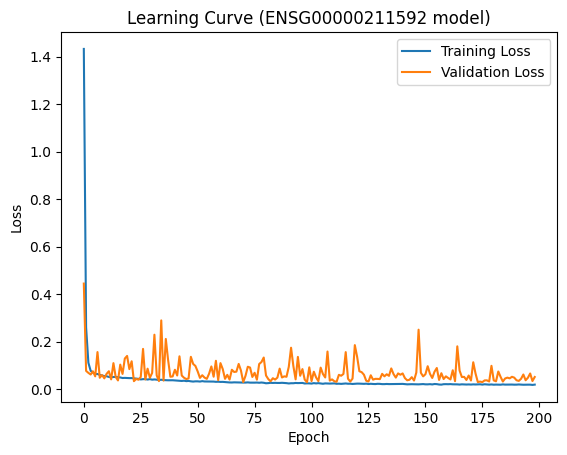

In [22]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curve (ENSG00000211592 model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/ENSG00000211592_learning_curve.svg', bbox_inches = 'tight')
plt.show()

In [23]:
train_loss = history.history['loss'][-1]
train_mae = history.history['mae'][-1]
print(f"Training Loss: {train_loss:.4f}")
print(f"Training MAE: {train_mae:.4f}")

Training Loss: 0.0196
Training MAE: 0.1075


In [24]:
val_loss = history.history['val_loss'][-1]
val_mae = history.history['val_mae'][-1]
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation MAE: {val_mae:.4f}")

Validation Loss: 0.0516
Validation MAE: 0.1870


In [25]:
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

Test Loss: 0.0417
Test MAE: 0.1667


In [26]:
predictions = model.predict(X_test)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


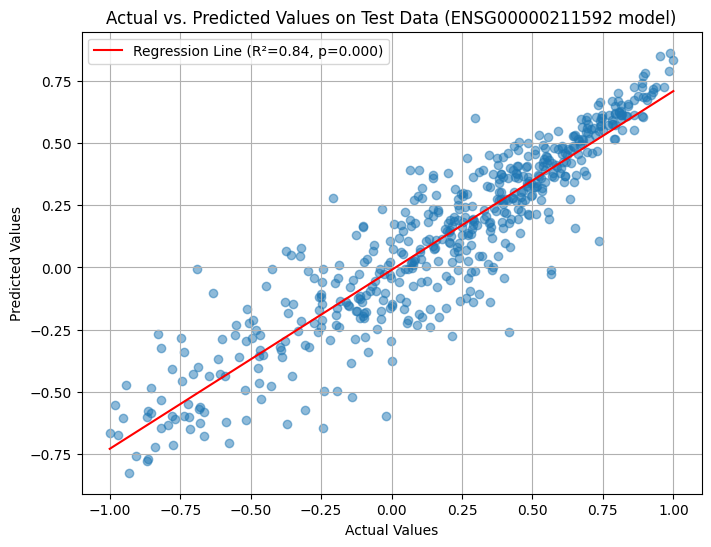

R-squared: 0.8415
P-value: 0.0000


In [27]:
from scipy.stats import linregress
import matplotlib.pyplot as plt
import numpy as np

# Calculate the regression line and statistics
slope, intercept, r_value, p_value, std_err = linregress(y_test.flatten(), predictions.flatten())

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5)

x_values = np.array([y_test.min(), y_test.max()])
plt.plot(x_values, intercept + slope * x_values, color='red', label=f'Regression Line (R²={r_value**2:.2f}, p={p_value:.3f})')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values on Test Data (ENSG00000211592 model)")
plt.grid(True)
plt.legend()
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/ENSG00000211592_Reg_plot_actual_pred_.svg', bbox_inches = 'tight')
plt.show()

print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4f}")